In [51]:
import xarray as xr
import rioxarray
import xvec
import geopandas as gpd
import pandas as pd
import shapely
from itertools import product
import numpy as np
from matplotlib import pyplot as plt

In [2]:
aois = gpd.read_file("../data_working/deadtrees_aoi.gpkg").to_crs(3857)

In [22]:
def preprocess(ds: xr.Dataset) -> xr.Dataset:
    yr = int(ds.encoding["source"].split("_")[-1][:4])
    return ds.isel(band=0).rename(band="time").assign_coords(time=[yr])

deadwood_years = list(range(2017, 2026))

deadwood_urls = [
    f"https://data2.deadtrees.earth/assets/v1/dte_maps/run_v1004_v1000_crop_half_fold_None_checkpoint_199_deadwood_{yr}.cog.tif"
    for yr in deadwood_years
]

deadwood_rasters = [
    xr.open_dataset(url, engine="rasterio").rename(band="time").assign_coords(time=[year, year]).rio.write_crs(3857)
    for url, year in zip(deadwood_urls, deadwood_years)
]

In [6]:
deadwood_bounds = deadwood_rasters[0].rio.bounds()
aois_subset = aois[~aois.clip_by_rect(*deadwood_bounds).geometry.is_empty]
print(f"Found {aois_subset.shape[0]} geometries in bounds")

Found 167 geometries in bounds


In [15]:
bbox = shapely.buffer(aois_subset.geometry.iloc[0], 100).bounds

clips = [
    r.rio.clip_box(*bbox) for r in deadwood_rasters
]

In [38]:
def do_zonal_stats(geom, rast):
    bbox = shapely.buffer(geom, 100).bounds
    raster_clip = rast.rio.clip_box(*bbox)
    return raster_clip.xvec.zonal_stats([geom], "x", "y").band_data.data[0][0]

do_zonal_stats(aois_subset.geometry.iloc[0], deadwood_rasters[0])

9.229093

In [39]:
from tqdm.autonotebook import tqdm

/tmp/ipykernel_1101/987820437.py:1: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [40]:
zs_results = []
for (row, rast) in tqdm(product(aois_subset.iterrows(), deadwood_rasters)):
    dataset_id = row[1]["dataset_id"]
    year = rast.time.data[0]
    mean = do_zonal_stats(row[1]["geometry"], rast)
    zs_results.append((dataset_id, year, mean))

0it [00:00, ?it/s]

In [63]:
deadwood_over_time = pd.DataFrame(zs_results, columns=["dataset_id", "year", "deadwood_mean_pct"])
deadwood_over_time["deadwood_mean_pct"] = deadwood_over_time["deadwood_mean_pct"] / 255 * 100

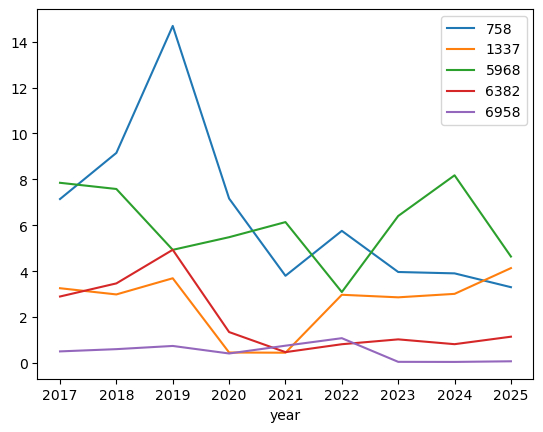

In [65]:
dataset_sample = np.random.choice(deadwood_over_time["dataset_id"].unique(), size=5)

fig, ax = plt.subplots()
for label, grp in deadwood_over_time[deadwood_over_time["dataset_id"].isin(dataset_sample)].groupby("dataset_id"):
    grp.plot(x = "year", y = "deadwood_mean_pct", ax = ax, label = label)

plt.show()

In [66]:
deadwood_over_time.to_csv("../data_working/deadtrees_europe_ann_mean_deadwood.csv")